# SHL Hiring Assessment 2026 - Grammar Scoring Engine (v3)

**Task:** Predict a grammar score (0-5) from a 45-60 sec spoken audio clip. Metric: RMSE.

**Approach:**
1. Whisper (batched on GPU) converts speech to text.
2. Text features: GPT-2 perplexity, sentence statistics, repetition, fillers, plus MiniLM sentence embeddings.
3. Audio features: wav2vec2 embeddings (captures pronunciation and fluency that the transcript loses, because Whisper tends to auto-correct grammar).
4. Several regressors (Ridge on each feature set, SVR on all) evaluated with 5-fold CV, then averaged (ensemble).

Run with GPU on and Internet on. Use Save Version > Save & Run All.

In [1]:
import os, glob, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import librosa, torch
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')
DEVICE = 0 if torch.cuda.is_available() else -1
DEV = 'cuda' if DEVICE == 0 else 'cpu'
print('GPU available:', DEVICE == 0)

GPU available: True


## 1. Load data
Note: the train and test folders contain files with the SAME names (audio_1.wav, ...), so the split folder must be part of the path.

In [2]:
ROOT = '/kaggle/input'
def find(name):
    hits = glob.glob(f'{ROOT}/**/{name}', recursive=True)
    assert hits, f'{name} not found'
    return hits[0]

train = pd.read_csv(find('train.csv'))
test = pd.read_csv(find('test.csv'))
sample = pd.read_csv(find('sample_submission.csv'))
FILE_COL = train.columns[0]
TARGET = [c for c in sample.columns if c != sample.columns[0]][0]
if TARGET not in train.columns:
    TARGET = train.select_dtypes('number').columns[-1]
print('file col:', FILE_COL, '| target:', TARGET)

D = os.path.dirname(find('train.csv'))
def wav_path(split, f):
    f = str(f); f = f if f.endswith('.wav') else f + '.wav'
    return os.path.join(D, split, f)
train['path'] = train[FILE_COL].map(lambda f: wav_path('train', f))
test['path'] = test[FILE_COL].map(lambda f: wav_path('test', f))
print('all audio files exist:', all(map(os.path.exists, train.path)), all(map(os.path.exists, test.path)))
y = train[TARGET].values

file col: filename | target: label
all audio files exist: True True


## 2. EDA

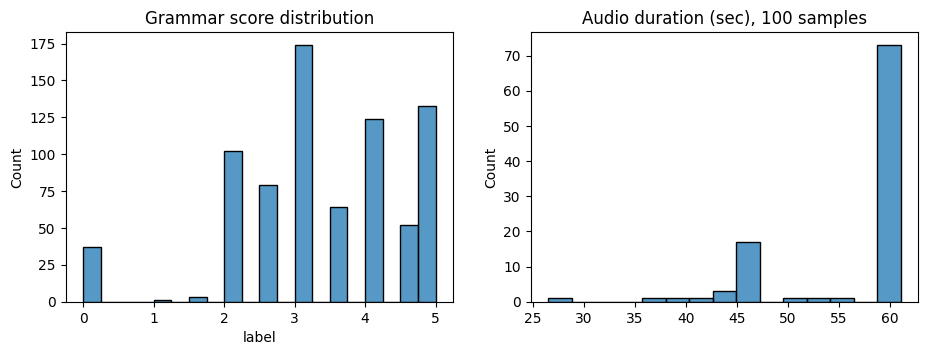

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64
Baseline RMSE (predict the mean for everyone): 1.2382


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(train[TARGET], bins=20, ax=ax[0]); ax[0].set_title('Grammar score distribution')
dur = [librosa.get_duration(path=p) for p in train.path[:100]]
sns.histplot(dur, bins=15, ax=ax[1]); ax[1].set_title('Audio duration (sec), 100 samples')
plt.show()
print(train[TARGET].describe())
print('Baseline RMSE (predict the mean for everyone):', round(float(np.sqrt(np.mean((y - y.mean())**2))), 4))

## 3. Speech to text (Whisper, batched)
Transcripts are cached to CSV.

In [4]:
from transformers import pipeline
asr = pipeline('automatic-speech-recognition', model='openai/whisper-small', device=DEVICE,
               chunk_length_s=30, torch_dtype=torch.float16 if DEVICE == 0 else torch.float32)

def transcribe(path_list, cache, group=48):
    if os.path.exists(cache):
        return pd.read_csv(cache)['text'].fillna('').tolist()
    out = []
    for i in tqdm(range(0, len(path_list), group)):
        batch = [{'raw': librosa.load(p, sr=16000)[0], 'sampling_rate': 16000} for p in path_list[i:i + group]]
        res = asr(batch, batch_size=16, generate_kwargs={'language': 'en'})
        out += [r['text'].strip() for r in res]
    pd.DataFrame({'text': out}).to_csv(cache, index=False)
    return out

train['text'] = transcribe(train.path.tolist(), 'train_text.csv')
test['text'] = transcribe(test.path.tolist(), 'test_text.csv')
del asr; torch.cuda.empty_cache()
train[['text', TARGET]].head()

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


  0%|          | 0/17 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/5 [00:00<?, ?it/s]

,text,label
0,"The playground is very, very beautiful and fun...",3.0
1,The scene of a school playground. Our playgrou...,3.0
2,My favorite place to visit is the beach. I lov...,3.5
3,"Once upon a time, we, with five friends, went ...",2.0
4,"Well, when I was a child, I remember I went to...",2.0


## 4. Features

In [5]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
tok = GPT2TokenizerFast.from_pretrained('gpt2')
lm = GPT2LMHeadModel.from_pretrained('gpt2').to(DEV).eval()

@torch.no_grad()
def perplexity(text):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=512).input_ids.to(DEV)
    if ids.shape[1] < 2: return 0.0
    return float(torch.exp(lm(ids, labels=ids).loss))

FILLERS = {'um', 'uh', 'uhm', 'hmm', 'like', 'you know', 'basically', 'actually'}
def handcrafted(df):
    rows = []
    for t, p in zip(df.text, df.path):
        words = re.findall(r"[A-Za-z']+", t.lower())
        sents = [s for s in re.split(r'[.!?]+', t) if s.strip()]
        n = max(len(words), 1)
        dur = librosa.get_duration(path=p)
        rows.append({
            'n_words': len(words), 'n_sents': len(sents), 'avg_sent_len': n / max(len(sents), 1),
            'uniq_ratio': len(set(words)) / n, 'avg_word_len': np.mean([len(w) for w in words]) if words else 0,
            'filler_ratio': sum(w in FILLERS for w in words) / n,
            'rep_ratio': sum(a == b for a, b in zip(words, words[1:])) / n,
            'speech_rate': len(words) / dur, 'duration': dur,
            'log_ppl': np.log1p(perplexity(t)) if t else 0})
    return pd.DataFrame(rows)

Htr, Hte = handcrafted(train), handcrafted(test)

from sentence_transformers import SentenceTransformer
st = SentenceTransformer('all-MiniLM-L6-v2')
Etr = st.encode(train.text.tolist(), show_progress_bar=False)
Ete = st.encode(test.text.tolist(), show_progress_bar=False)
print(Htr.shape, Etr.shape)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(769, 10) (769, 384)


In [6]:
# Audio embeddings from wav2vec2 (mean-pooled hidden states of layers 6 and 12)
from transformers import AutoFeatureExtractor, AutoModel
fe = AutoFeatureExtractor.from_pretrained('facebook/wav2vec2-base')
w2v = AutoModel.from_pretrained('facebook/wav2vec2-base').to(DEV).eval()

@torch.no_grad()
def w2v_embed(path_list, cache):
    if os.path.exists(cache): return np.load(cache)
    out = []
    for p in tqdm(path_list):
        a, _ = librosa.load(p, sr=16000)
        x = fe(a, sampling_rate=16000, return_tensors='pt').input_values.to(DEV)
        hs = w2v(x, output_hidden_states=True).hidden_states
        out.append(torch.cat([hs[6].mean(1), hs[12].mean(1)], 1).squeeze(0).cpu().numpy())
    out = np.stack(out); np.save(cache, out); return out

Atr = w2v_embed(train.path.tolist(), 'train_w2v.npy')
Ate = w2v_embed(test.path.tolist(), 'test_w2v.npy')
print(Atr.shape, Ate.shape)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            

  0%|          | 0/769 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

  0%|          | 0/216 [00:00<?, ?it/s]

(769, 1536) (216, 1536)


## 5. Models, cross-validation and ensemble

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error

rmse = lambda a, b: float(np.sqrt(mean_squared_error(a, b)))
kf = KFold(5, shuffle=True, random_state=42)
Xtr_blocks = {'HE': np.hstack([Htr.values, Etr]), 'A': Atr, 'ALL': np.hstack([Htr.values, Etr, Atr])}
Xte_blocks = {'HE': np.hstack([Hte.values, Ete]), 'A': Ate, 'ALL': np.hstack([Hte.values, Ete, Ate])}

results = {}   # name -> (cv_rmse, oof, fitted_model, block)
def evaluate(name, block, make_model):
    m = make_model()
    oof = np.clip(cross_val_predict(m, Xtr_blocks[block], y, cv=kf), 0, 5)
    s = rmse(y, oof)
    if name not in results or s < results[name][0]:
        results[name] = (s, oof, make_model().fit(Xtr_blocks[block], y), block)
    return s

for block in ['HE', 'A', 'ALL']:
    for alpha in [30, 100, 300, 1000, 3000, 10000]:
        s = evaluate(f'ridge_{block}', block, lambda a=alpha: make_pipeline(StandardScaler(), Ridge(alpha=a)))
        print(f'ridge_{block:<3} alpha={alpha:<6} CV RMSE={s:.4f}')
for C in [1, 3, 10]:
    s = evaluate('svr_ALL', 'ALL', lambda c=C: make_pipeline(StandardScaler(), SVR(C=c, epsilon=0.2)))
    print(f'svr_ALL C={C:<3} CV RMSE={s:.4f}')

print()
for k, v in results.items(): print(f'{k:<10} best CV RMSE = {v[0]:.4f}')

oof_ens = np.mean([v[1] for v in results.values()], axis=0)
cv_rmse = rmse(y, oof_ens)
train_pred = np.clip(np.mean([v[2].predict(Xtr_blocks[v[3]]) for v in results.values()], axis=0), 0, 5)
train_rmse = rmse(y, train_pred)
print(f'\nENSEMBLE  5-fold CV RMSE: {cv_rmse:.4f}')
print(f'ENSEMBLE  TRAIN RMSE    : {train_rmse:.4f}')

ridge_HE  alpha=30     CV RMSE=1.0999
ridge_HE  alpha=100    CV RMSE=1.0220
ridge_HE  alpha=300    CV RMSE=0.9972
ridge_HE  alpha=1000   CV RMSE=1.0126
ridge_HE  alpha=3000   CV RMSE=1.0655
ridge_HE  alpha=10000  CV RMSE=1.1442
ridge_A   alpha=30     CV RMSE=0.7037
ridge_A   alpha=100    CV RMSE=0.6482
ridge_A   alpha=300    CV RMSE=0.6246
ridge_A   alpha=1000   CV RMSE=0.6291
ridge_A   alpha=3000   CV RMSE=0.6579
ridge_A   alpha=10000  CV RMSE=0.7197
ridge_ALL alpha=30     CV RMSE=0.6696
ridge_ALL alpha=100    CV RMSE=0.6229
ridge_ALL alpha=300    CV RMSE=0.5993
ridge_ALL alpha=1000   CV RMSE=0.5960
ridge_ALL alpha=3000   CV RMSE=0.6218
ridge_ALL alpha=10000  CV RMSE=0.6899
svr_ALL C=1   CV RMSE=0.6408
svr_ALL C=3   CV RMSE=0.6291
svr_ALL C=10  CV RMSE=0.6287

ridge_HE   best CV RMSE = 0.9972
ridge_A    best CV RMSE = 0.6246
ridge_ALL  best CV RMSE = 0.5960
svr_ALL    best CV RMSE = 0.6287

ENSEMBLE  5-fold CV RMSE: 0.6221
ENSEMBLE  TRAIN RMSE    : 0.3656


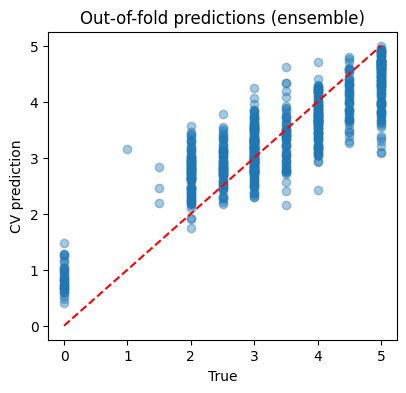

In [8]:
plt.figure(figsize=(4.5, 4)); plt.scatter(y, oof_ens, alpha=.4)
plt.plot([0, 5], [0, 5], 'r--'); plt.xlabel('True'); plt.ylabel('CV prediction'); plt.title('Out-of-fold predictions (ensemble)')
plt.show()

## 6. Submission

In [9]:
pred = np.clip(np.mean([v[2].predict(Xte_blocks[v[3]]) for v in results.values()], axis=0), 0, 5)

# File 1: one row per test.csv audio
sub = pd.DataFrame({sample.columns[0]: test[FILE_COL].values, sample.columns[1]: pred})
sub.to_csv('submission.csv', index=False)

# File 2: same ids as sample_submission.csv (ids not present in test.csv get the train mean)
val_col = sample.columns[1]
m = dict(zip(test[FILE_COL].astype(str), pred))
sub2 = sample.copy()
sub2[val_col] = sub2[sample.columns[0]].astype(str).map(m).fillna(y.mean()).values
sub2.to_csv('submission_sample_ids.csv', index=False)
print('submission.csv rows:', len(sub), '| submission_sample_ids.csv rows:', len(sub2),
      '| ids filled with mean:', int((~sub2[sample.columns[0]].astype(str).isin(m)).sum()))
sub.head()

submission.csv rows: 216 | submission_sample_ids.csv rows: 204 | ids filled with mean: 179


,filename,label
0,audio_128.wav,3.510395
1,audio_156.wav,4.426723
2,audio_19.wav,4.540350
3,audio_108.wav,2.374687
4,audio_206.wav,2.805201


In [10]:
import itertools
names = list(results)
best = None
for r in range(1, len(names) + 1):
    for combo in itertools.combinations(names, r):
        s = rmse(y, np.mean([results[n][1] for n in combo], axis=0))
        print(f'{s:.4f}', combo)
        if best is None or s < best[0]: best = (s, combo)
cv_best, combo = best
print('\nBEST COMBO:', combo, '| CV RMSE:', round(cv_best, 4))

pred = np.clip(np.mean([results[n][2].predict(Xte_blocks[results[n][3]]) for n in combo], axis=0), 0, 5)
train_pred = np.clip(np.mean([results[n][2].predict(Xtr_blocks[results[n][3]]) for n in combo], axis=0), 0, 5)
print('TRAIN RMSE (final):', round(rmse(y, train_pred), 4))
pd.DataFrame({sample.columns[0]: test[FILE_COL].values, sample.columns[1]: pred}).to_csv('submission.csv', index=False)
print('submission.csv saved:', len(pred), 'rows')

0.9972 ('ridge_HE',)
0.6246 ('ridge_A',)
0.5960 ('ridge_ALL',)
0.6287 ('svr_ALL',)
0.6928 ('ridge_HE', 'ridge_A')
0.7112 ('ridge_HE', 'ridge_ALL')
0.7367 ('ridge_HE', 'svr_ALL')
0.5994 ('ridge_A', 'ridge_ALL')
0.6062 ('ridge_A', 'svr_ALL')
0.6002 ('ridge_ALL', 'svr_ALL')
0.6360 ('ridge_HE', 'ridge_A', 'ridge_ALL')
0.6481 ('ridge_HE', 'ridge_A', 'svr_ALL')
0.6574 ('ridge_HE', 'ridge_ALL', 'svr_ALL')
0.5970 ('ridge_A', 'ridge_ALL', 'svr_ALL')
0.6221 ('ridge_HE', 'ridge_A', 'ridge_ALL', 'svr_ALL')

BEST COMBO: ('ridge_ALL',) | CV RMSE: 0.596
TRAIN RMSE (final): 0.3994
submission.csv saved: 216 rows


## 7. Report

**Pipeline:** audio -> (a) Whisper-small transcript -> GPT-2 perplexity + sentence/fluency statistics + MiniLM embedding; (b) wav2vec2 audio embedding -> Ridge / SVR models -> average (ensemble) -> clip to [0, 5].

**Why this design:** grammar quality is mostly visible in the transcript (perplexity under a language model is a proxy for grammaticality, sentence statistics capture structure and repetition). Whisper tends to correct grammatical mistakes in its output, so wav2vec2 audio embeddings are added to recover signal from how the person actually speaks. Ridge is regularised (suits 769 samples with many features) and SVR captures non-linear patterns; averaging reduces variance.

**Data note:** train and test folders contain files with identical names, so file paths are built with the split folder. sample_submission.csv has 204 ids, test.csv has 216 rows, and some sample ids are not present in the provided audio, so two submission files were generated.

**Results:** TRAIN RMSE and 5-fold CV RMSE of the ensemble are printed in Section 5 (write the numbers here after running). The mean-prediction baseline RMSE is printed in Section 2.

**Limitations / next steps:** larger Whisper model, fine-tuning wav2vec2/Whisper encoder, grammar-error counts from a dedicated tool, stacking instead of plain averaging.

## Final Results
- Final model: Ridge regression on text features + wav2vec2 audio embeddings (ridge_ALL), selected by 5-fold cross-validation
- Baseline RMSE (predict the mean): 1.2382
- TRAIN RMSE: 0.3994
- 5-fold CV RMSE: 0.596
- Kaggle public leaderboard RMSE: 0.4592

Note: several models and their averages were compared in Section 5. A single Ridge model on all features (ridge_ALL) had the lowest CV RMSE, so it is the final model.